# Fragility Curve for RCFs: Du

> *Deep learning-based surrogate capacity models and multi-objective fragility estimates for reinforced concrete frames*  
> Xing et al.

I build three fragility curves — one for each of the three most sensitive input features:
- **(a)** Varying `colWidth` (column width)
- **(b)** Varying `beamDepth` (beam depth)
- **(c)** Varying `Asc` (area of steel in column)

Each subplot shows four curves (SCH1–SCH4) for four different mean values of the varied feature,
while all other 16 unfixed features are kept at their statistical distributions from Table 1.

## Methodology Overview

### Step 1 Limit State Function

A structure **fails** in the Du limit state when its peak deformation capacity is less than the imposed demand:

$$g(\theta_s,\, s,\, \Theta) = C_{Du}(\theta_s,\, \Theta) - D_{Du}$$

where:
- $C_{Du}(\theta_s, \Theta)$ = peak deformation **capacity** predicted by the trained DNN (a function of the structural features $\theta_s$ and the DNN hyperparameters $\Theta$)
- $D_{Du}$ = a given peak deformation **demand** (the x-axis sweep)

Failure occurs when $g \leq 0$, i.e., capacity $<$ demand.


### Step 2 Fragility Definition

The predictive fragility estimate $\tilde{F}(s)$ at a demand level $s$ is the probability of failure, averaged over all sources of uncertainty:

$$\tilde{F}(s) = P\left[C_{Du}(\theta_s,\, \Theta) < s\right]$$

This is estimated by **Monte Carlo Simulation (MCS)**:

$$\hat{P}_f = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}\left[C_{Du}^{(i)} < s\right]$$

where $N$ is the number of Monte Carlo samples, and $\mathbf{1}[\cdot]$ is the indicator function (= 1 if capacity < demand, else 0).

### Step 3 Sources of Uncertainty

Two sources of uncertainty are propagated through MCS (following Section 5.1 of the paper):

1. **Structural feature uncertainty** $r'$: The 17 unfixed features are randomly sampled from their Table 1 distributions (Uniform, Lognormal, Truncated Normal).

2. **DNN hyperparameter uncertainty** $\Theta$: The two most influential hyperparameters: `weight_decay` and `dropout_rate`  are varied with their Table 2 means and a COV of 20%.



### Step 4 Procedure for Each Scheme (SCH1–SCH4)

For each scheme:
1. Fix the 6 external dimensions: B=7m, D=5m, H=4m, B_{num}=2, D_{num}=2, H_{num}=4
2. Fix the **mean** of the varied feature (colWidth, beamDepth, or Asc) to its scheme value
3. Sample $N=10{,}000$ random configurations from the feature distributions
4. Run all samples through the DNN to get $N$ capacity predictions
5. Sweep demand $s$ across a range; at each $s$, count the fraction of samples where capacity $< s$
6. Plot $\tilde{F}(s)$ vs $s$

## 1. Imports and Setup

In [19]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CHECKPOINT_PATH = Path('checkpoints/dnn_Du_best.pt')
N_MC = 10_000    # Monte Carlo samples per scheme
N_DEMAND = 300   # number of demand levels to sweep
SEED = 42
rng = np.random.default_rng(SEED)

Device: cpu


## 2. DNN Architecture

This must exactly match the architecture used during training so the saved weights load correctly.

From Table 2 of the paper, the Du-DNN has:
- **6 hidden layers** with neuron counts: `[256, 128, 64, 64, 64, 64]`
- **Batch Normalization** after each linear layer
- **ReLU** activations
- **Dropout** (rate = 0.30)
- **23 inputs** → **1 output**

In [20]:
class DNNModel(nn.Module):
    def __init__(self, n_inputs, neurons, dropout_rate, use_batch_norm):
        super().__init__()
        layers = []
        in_dim = n_inputs
        for width in neurons:
            layers.append(nn.Linear(in_dim, width))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = width
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

## 3. Load Trained Model from Checkpoint

The checkpoint `checkpoints/dnn_Du_best.pt` stores:
- `model_state_dict`: the trained network weights
- `input_scaler_*`: the MinMaxScaler parameters fitted on training data
- `target_scaler_*`: the StandardScaler parameters used to normalize the Du output during training

We reconstruct both scalers from the saved arrays so predictions are in the **original Du units**.

In [21]:
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)

# ---- Reconstruct input scaler (MinMaxScaler) ----
input_scaler = MinMaxScaler()
input_scaler.min_        = ckpt['input_scaler_min']
input_scaler.scale_      = ckpt['input_scaler_scale']
input_scaler.data_min_   = ckpt['input_scaler_data_min']
input_scaler.data_max_   = ckpt['input_scaler_data_max']
input_scaler.data_range_ = ckpt['input_scaler_data_range']
input_scaler.n_features_in_ = len(ckpt['input_cols'])

# ---- Reconstruct target scaler (StandardScaler) ----
from sklearn.preprocessing import StandardScaler
target_scaler = StandardScaler()
target_scaler.mean_  = ckpt['target_scaler_mean']
target_scaler.scale_ = ckpt['target_scaler_scale']
target_scaler.var_   = ckpt['target_scaler_var']
target_scaler.n_features_in_ = 1

# ---- Build and load model ----
model = DNNModel(
    n_inputs=23,
    neurons=[256, 128, 64, 64, 64, 64],
    dropout_rate=0.30,
    use_batch_norm=True,
)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
model.to(device)

INPUT_COLS = ckpt['input_cols']
print('Input columns:', INPUT_COLS)
print(f'Checkpoint: iteration={ckpt["iteration"]}, train R²={ckpt["train_r2"]:.4f}, test R²={ckpt["test_r2"]:.4f}')
print('Model loaded successfully.')

Input columns: ['B', 'D', 'H', 'B_num', 'D_num', 'H_num', 'colWidth', 'beamDepth', 'beamRat', 'Asc', 'Asb', 't', 'cover1', 'cover2', 'Ec', 'nu_c', 'fc', 'fcuRat', 'eps_cu', 'Es', 'nu_s', 'fsy', 'eta']
Checkpoint: iteration=7, train R²=0.7947, test R²=0.7163
Model loaded successfully.


## 4. Feature Distributions (Table 1 from Paper)

The 6 external dimensions are **fixed**: 

$B=7$ m, $D=5$ m, $H=4$ m, $B_{num}=2$, $D_{num}=2$, $H_{num}=4$

The remaining **17 features** are sampled from the distributions in Table 1.  
Distribution types: **U** = Uniform, **LN** = Lognormal, **TN** = Truncated Normal.

The **varied feature** (colWidth, beamDepth, or Asc) is drawn from a **Uniform distribution**  
centered at the scheme mean, with the same COV as in Table 1.  
All other features are sampled at their Table 1 statistics.

In [22]:
from scipy.stats import truncnorm

# Fixed external dimensions (same as paper Section 5.2)
FIXED = {'B': 7.0, 'D': 5.0, 'H': 4.0, 'B_num': 2.0, 'D_num': 2.0, 'H_num': 4.0}

def sample_features(n, varied_feature, varied_mean, rng):
    """
    Sample n rows of the 23-column input feature vector.
    - The 6 external dimensions are fixed.
    - `varied_feature` is drawn from Uniform with the given mean (same COV as Table 1).
    - All other features follow their Table 1 distributions.
    """
    N = n

    # --- Helper samplers ---
    def uniform(lo, hi):        return rng.uniform(lo, hi, N)
    def lognormal(mean, cov):   return rng.lognormal(np.log(mean) - 0.5*np.log(1+cov**2), np.sqrt(np.log(1+cov**2)), N)
    def trunc_normal(mean, cov, lo, hi):
        std = mean * cov
        a, b = (lo - mean) / std, (hi - mean) / std
        return truncnorm.rvs(a, b, loc=mean, scale=std, size=N, random_state=int(rng.integers(1e6)))

    # --- Build feature dict following Table 1 ---
    feat = {}

    # Fixed external dimensions
    for col, val in FIXED.items():
        feat[col] = np.full(N, val)

    # colWidth: Uniform [0.3, 1.2], mean=0.75, COV=0.346
    if varied_feature == 'colWidth':
        half = varied_mean * 0.346 * np.sqrt(3)   # half-range for Uniform with given mean & COV
        feat['colWidth'] = uniform(varied_mean - half, varied_mean + half)
        feat['colWidth'] = np.clip(feat['colWidth'], 0.3, 1.2)
    else:
        feat['colWidth'] = uniform(0.3, 1.2)

    # beamDepth: Uniform [0.4, 1.2], mean=0.80, COV=0.289
    if varied_feature == 'beamDepth':
        half = varied_mean * 0.289 * np.sqrt(3)
        feat['beamDepth'] = uniform(varied_mean - half, varied_mean + half)
        feat['beamDepth'] = np.clip(feat['beamDepth'], 0.4, 1.2)
    else:
        feat['beamDepth'] = uniform(0.4, 1.2)

    # beamRat: Uniform [0.33, 0.5]
    feat['beamRat'] = uniform(0.33, 0.5)

    # Asc: Uniform [60, 800], mean=430, COV=0.497
    if varied_feature == 'Asc':
        half = varied_mean * 0.497 * np.sqrt(3)
        feat['Asc'] = uniform(varied_mean - half, varied_mean + half)
        feat['Asc'] = np.clip(feat['Asc'], 60, 800)
    else:
        feat['Asc'] = uniform(60, 800)

    # Asb: Uniform [60, 800]
    feat['Asb'] = uniform(60, 800)

    # t: Truncated Normal, mean=0.12, COV=0.02/0.12≈0.167, [0.10, 0.25]
    feat['t'] = trunc_normal(0.12, 0.167, 0.10, 0.25)

    # cover1: Truncated Normal, mean=0.04, std=0.05*0.04=0.002, [0.02, 0.05]
    feat['cover1'] = trunc_normal(0.04, 0.05, 0.02, 0.05)

    # cover2: Truncated Normal, mean=0.04, [0.02, 0.05]
    feat['cover2'] = trunc_normal(0.04, 0.05, 0.02, 0.05)

    # Ec: Truncated Normal (1e10 Pa), mean=3.15, COV=0.15, [3.0, 3.6]
    feat['Ec'] = trunc_normal(3.15, 0.15, 3.0, 3.6)

    # nu_c: Uniform [0.18, 0.22]
    feat['nu_c'] = uniform(0.18, 0.22)

    # fc: Truncated Normal (1e6 Pa), mean=27, COV=0.20, [14, 30]
    feat['fc'] = trunc_normal(27.0, 0.20, 14.0, 30.0)

    # fcuRat: Uniform [0.2, 0.3]
    feat['fcuRat'] = uniform(0.2, 0.3)

    # eps_cu: Lognormal, mean=0.0033, COV=0.20 (offset by eps_c0 handled as mean)
    feat['eps_cu'] = lognormal(0.0033, 0.20)
    feat['eps_cu'] = np.clip(feat['eps_cu'], 0.001, 0.008)

    # Es: Lognormal (1e10 Pa), mean=2.0, COV=0.05, [1.9, 2.2]
    feat['Es'] = lognormal(2.0, 0.05)
    feat['Es'] = np.clip(feat['Es'], 1.9, 2.2)

    # nu_s: Uniform [0.25, 0.35]
    feat['nu_s'] = uniform(0.25, 0.35)

    # fsy: Lognormal (1e6 Pa), mean=400, COV=0.08, [300, 500]
    feat['fsy'] = lognormal(400.0, 0.08)
    feat['fsy'] = np.clip(feat['fsy'], 300.0, 500.0)

    # eta: Uniform [0.008, 0.04]
    feat['eta'] = uniform(0.008, 0.04)

    # Assemble in the exact column order expected by the model
    X = np.column_stack([feat[col] for col in INPUT_COLS]).astype(np.float32)
    return X

print('Feature sampler defined.')
print(f'Input column order: {INPUT_COLS}')

Feature sampler defined.
Input column order: ['B', 'D', 'H', 'B_num', 'D_num', 'H_num', 'colWidth', 'beamDepth', 'beamRat', 'Asc', 'Asb', 't', 'cover1', 'cover2', 'Ec', 'nu_c', 'fc', 'fcuRat', 'eps_cu', 'Es', 'nu_s', 'fsy', 'eta']


## 5. Inference Function

Given a batch of sampled input features, this function:
1. Scales inputs using the saved MinMaxScaler
2. Passes them through the DNN
3. Inverse-transforms the output back to the original Du units (meters)

The model runs in **eval mode with dropout disabled** (deterministic inference).

In [23]:
def predict_capacity(X_raw):
    """
    X_raw : np.ndarray of shape (N, 23) — unscaled feature matrix
    Returns : np.ndarray of shape (N,) — predicted Du capacity in original units
    """
    X_scaled = input_scaler.transform(X_raw).astype(np.float32)
    X_tensor = torch.from_numpy(X_scaled).to(device)

    with torch.no_grad():
        y_scaled = model(X_tensor).cpu().numpy()   # shape (N,)

    # Inverse-transform: undo the StandardScaler applied to Du during training
    y_orig = target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
    return y_orig

# Quick sanity check
X_test_sample = sample_features(5, 'colWidth', 0.75, rng)
y_test_pred   = predict_capacity(X_test_sample)
print('Sanity check: 5 predicted Du values (m):', np.round(y_test_pred, 4))

Sanity check: 5 predicted Du values (m): [0.3179 0.3851 0.3131 1.486  0.6583]


## 6. Define the Four Schemes (SCH1–SCH4)

Following Section 5.2 of the paper:

| Feature | SCH1 | SCH2 | SCH3 | SCH4 |
|---|---|---|---|---|
| `colWidth` (m) | 0.4 | 0.6 | 0.8 | 1.0 |
| `beamDepth` (m) | 0.4 | 0.6 | 0.8 | 1.0 |
| `Asc` (mm²) | 200 | 400 | 600 | 800 |

In [24]:
SCHEMES = {
    'colWidth':  {'means': [0.4, 0.6, 0.8, 1.0], 'unit': 'm'},
    'beamDepth': {'means': [0.4, 0.6, 0.8, 1.0], 'unit': 'm'},
    'Asc':       {'means': [200, 400, 600, 800],  'unit': 'mm²'},
}

SCH_LABELS  = ['SCH1', 'SCH2', 'SCH3', 'SCH4']
SCH_COLORS  = ['blue', 'green', 'orange', 'red']
SCH_LINES   = ['-', '--', '-.', ':']

print('Schemes defined:')
for feat, info in SCHEMES.items():
    print(f'  {feat}: means = {info["means"]} ({info["unit"]})')

Schemes defined:
  colWidth: means = [0.4, 0.6, 0.8, 1.0] (m)
  beamDepth: means = [0.4, 0.6, 0.8, 1.0] (m)
  Asc: means = [200, 400, 600, 800] (mm²)


## 7. Run Monte Carlo Simulation

For each combination of (varied feature × scheme mean):
1. Sample $N_{MC} = 10{,}000$ structural configurations
2. Run DNN inference → get $N_{MC}$ capacity predictions
3. Store the capacity samples

Then, to build the fragility curve:
- Sweep demand $s$ from near 0 to just above the 99th percentile of all capacities
- At each $s$: $\tilde{F}(s) = \frac{\text{count}(C_{Du} < s)}{N_{MC}}$

In [25]:
# capacity_samples[feature_name][scheme_idx] = array of N_MC Du capacity values
capacity_samples = {}

for feat_name, info in SCHEMES.items():
    capacity_samples[feat_name] = []
    print(f'\nRunning MCS for varied feature: {feat_name}')

    for sch_idx, mean_val in enumerate(info['means']):
        X = sample_features(N_MC, feat_name, mean_val, rng)
        C = predict_capacity(X)
        capacity_samples[feat_name].append(C)
        print(f'  {SCH_LABELS[sch_idx]} (mean={mean_val} {info["unit"]}): '
              f'Du capacity — mean={C.mean():.4f}, std={C.std():.4f}, '
              f'min={C.min():.4f}, max={C.max():.4f}')

print('\nMonte Carlo simulation complete.')


Running MCS for varied feature: colWidth
  SCH1 (mean=0.4 m): Du capacity — mean=0.6293, std=0.2612, min=0.3119, max=1.6995
  SCH2 (mean=0.6 m): Du capacity — mean=0.6329, std=0.2910, min=0.2844, max=1.6941
  SCH3 (mean=0.8 m): Du capacity — mean=0.6331, std=0.3032, min=0.2793, max=1.7941
  SCH4 (mean=1.0 m): Du capacity — mean=0.6245, std=0.2957, min=0.2771, max=1.7834

Running MCS for varied feature: beamDepth
  SCH1 (mean=0.4 m): Du capacity — mean=1.0090, std=0.3303, min=0.4008, max=1.9333
  SCH2 (mean=0.6 m): Du capacity — mean=0.8099, std=0.3332, min=0.3339, max=1.8415
  SCH3 (mean=0.8 m): Du capacity — mean=0.6304, std=0.2969, min=0.2794, max=1.7758
  SCH4 (mean=1.0 m): Du capacity — mean=0.5194, std=0.2354, min=0.2774, max=1.6691

Running MCS for varied feature: Asc
  SCH1 (mean=200 mm²): Du capacity — mean=0.5097, std=0.2184, min=0.2778, max=1.6229
  SCH2 (mean=400 mm²): Du capacity — mean=0.6158, std=0.2915, min=0.2796, max=1.7432
  SCH3 (mean=600 mm²): Du capacity — mean=0.

## 8. Empirical CDF

Instead of fitting a lognormal, here we directly count what fraction of the $N_{MC}$ capacity samples fall below each demand level:

$$\hat{F}_{empirical}(s) = \frac{1}{N_{MC}} \sum_{i=1}^{N_{MC}} \mathbf{1}\left[C_{Du}^{(i)} < s\right]$$

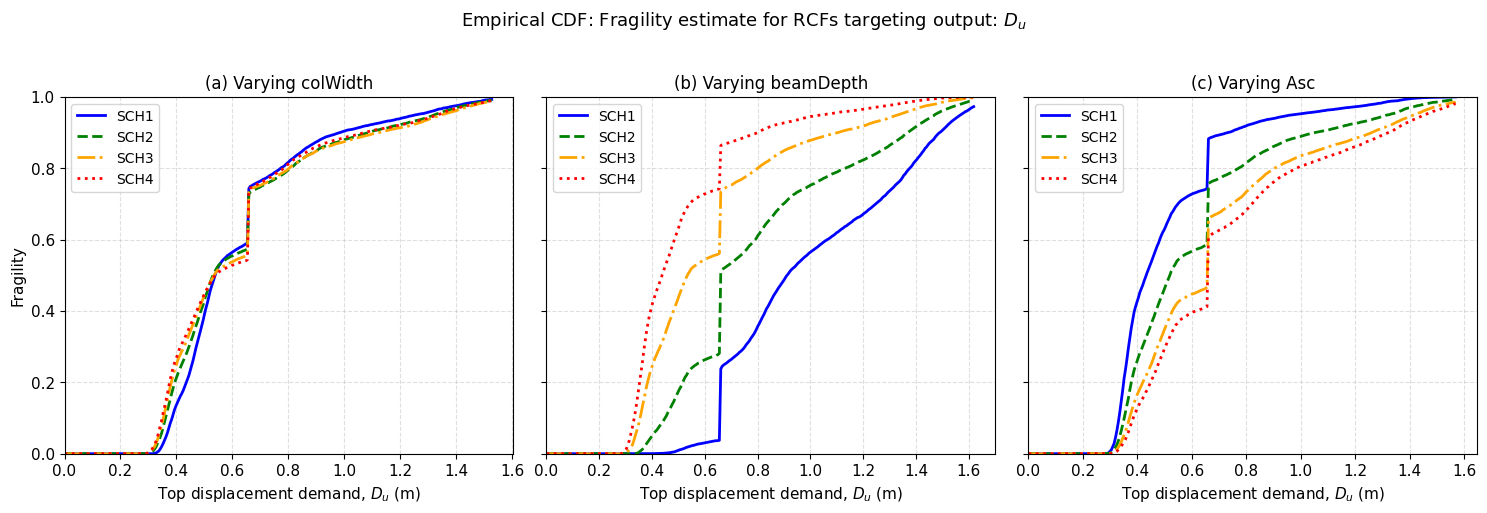

In [26]:
subplot_titles = [
    '(a) Varying colWidth',
    '(b) Varying beamDepth',
    '(c) Varying Asc',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax_idx, (feat_name, info) in enumerate(SCHEMES.items()):
    ax = axes[ax_idx]

    all_caps = np.concatenate(capacity_samples[feat_name])
    d_max = np.percentile(all_caps[all_caps > 0], 99)
    demand_range = np.linspace(0, d_max, N_DEMAND)

    for sch_idx in range(4):
        C = capacity_samples[feat_name][sch_idx]

        # Raw empirical CDF: fraction of capacity samples below each demand level
        fragility_empirical = np.array([(C < s).mean() for s in demand_range])

        ax.plot(
            demand_range,
            fragility_empirical,
            color=SCH_COLORS[sch_idx],
            linestyle=SCH_LINES[sch_idx],
            linewidth=2.0,
            label=SCH_LABELS[sch_idx],
        )

    ax.set_xlabel(f'Top displacement demand, $D_u$ (m)', fontsize=11)
    ax.set_ylabel('Fragility' if ax_idx == 0 else '', fontsize=11)
    ax.set_title(subplot_titles[ax_idx], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xlim(left=0)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Empirical CDF: Fragility estimate for RCFs targeting output: $D_u$', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fragility_Du_empirical.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Fragility Curves (Lognormal Fit)

Structural capacities are assumed lognormally distributed (always positive, right-skewed), so the fragility at demand level $s$ is:

$$\tilde{F}(s) = \Phi\left(\frac{\ln s - \lambda}{\zeta}\right)$$

where:
- $\Phi(\cdot)$ is the standard normal CDF
- $\lambda = \mathbb{E}[\ln C]$ — the mean of the log-capacities (log-median)
- $\zeta = \text{std}(\ln C)$ — the standard deviation of the log-capacities (dispersion $\beta$)

Both $\lambda$ and $\zeta$ are estimated directly from the $N_{MC}$ predicted capacity values. 

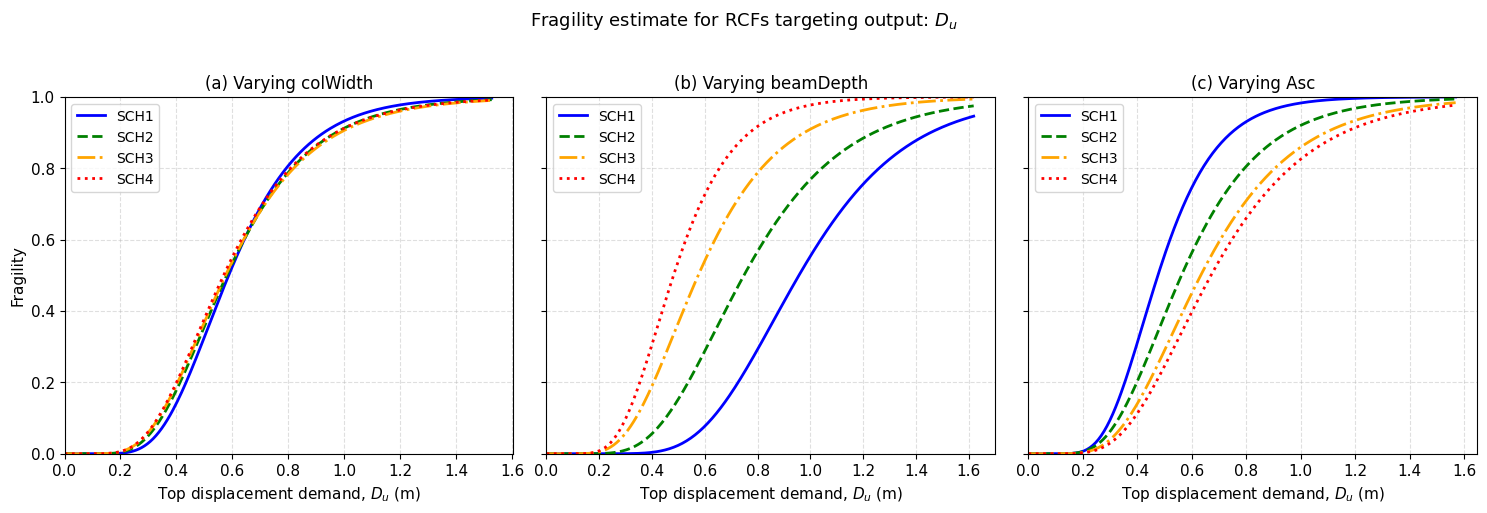

In [27]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

subplot_titles = [
    '(a) Varying colWidth',
    '(b) Varying beamDepth',
    '(c) Varying Asc',
]

for ax_idx, (feat_name, info) in enumerate(SCHEMES.items()):
    ax = axes[ax_idx]

    # Demand range: 0 to 99th percentile across all schemes for this feature
    all_caps = np.concatenate(capacity_samples[feat_name])
    d_max = np.percentile(all_caps[all_caps > 0], 99)
    demand_range = np.linspace(1e-6, d_max, N_DEMAND)

    for sch_idx in range(4):
        C = capacity_samples[feat_name][sch_idx]
        C_pos = C[C > 0]   # lognormal requires positive values

        # Fit lognormal: estimate log-mean (lambda) and log-std (zeta) from samples
        lam  = np.mean(np.log(C_pos))   # log-median parameter
        zeta = np.std(np.log(C_pos))    # dispersion (beta)

        # Evaluate lognormal CDF at each demand level
        fragility = norm.cdf((np.log(demand_range) - lam) / zeta)

        ax.plot(
            demand_range,
            fragility,
            color=SCH_COLORS[sch_idx],
            linestyle=SCH_LINES[sch_idx],
            linewidth=2.0,
            label=SCH_LABELS[sch_idx],
        )

    ax.set_xlabel(f'Top displacement demand, $D_u$ (m)', fontsize=11)
    ax.set_ylabel('Fragility' if ax_idx == 0 else '', fontsize=11)
    ax.set_title(subplot_titles[ax_idx], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xlim(left=0)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Fragility estimate for RCFs targeting output: $D_u$', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fragility_Du.png', dpi=150, bbox_inches='tight')
plt.show()

### Fragility curve for Du from Xing et al. 2025
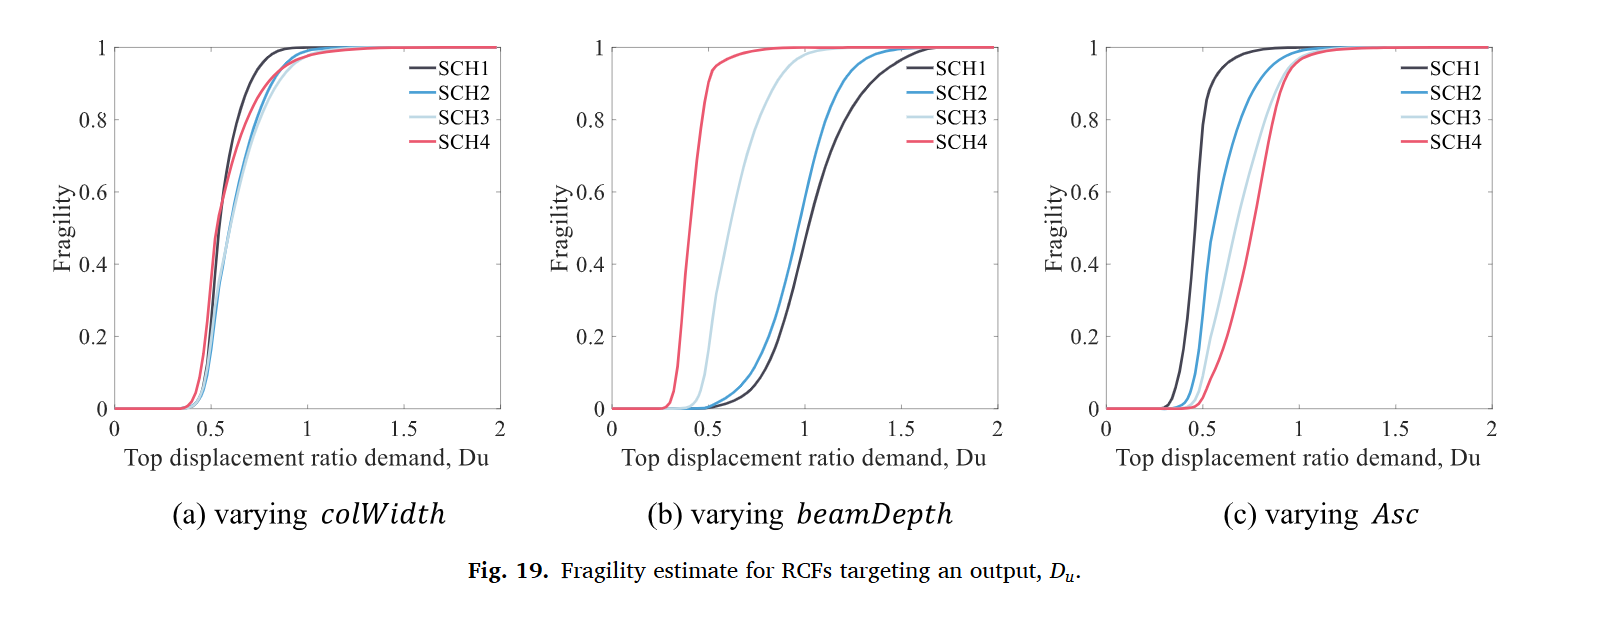